<a href="https://colab.research.google.com/github/manu675/ecommerce_cicd_colab/blob/main/rfm_analysis_with_ecommerce_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist comprehensive Ecommerce data set


Realistic Ecommerce data set of business relevance, which lends itself to producing real insights

*   Full order lifecycle (order $\rightarrow$ delivery $\rightarrow$ review)
*   100,000 orders from 2016-2018 (3 years)
*   customers, sellers, products, reviews

Aspects to analyze:

*   Customer behavior (e.g. repeat purchases, most valuable customers)
*   Logistics performance (delivery delays)
*   Revenue drivers






__MACOSX/ files aren't actual data; they are tiny metadata "resource forks" created by macOS that pandas can't parse as CSVs

## library imports

In [277]:
# data processing and visualization
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from zipfile import ZipFile

# preprocessing
from sklearn.preprocessing import StandardScaler # standard normalization

# modeling
from sklearn.cluster import KMeans
##from sklearn import linear_model
##from sklearn.model_selection import train_test_split
##from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

In [278]:
# Way 2: uploading the local data to google colab
# importing local data to google colab:

##from google.colab import files
##uploaded = files.upload()


In [279]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [280]:
!ls


shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
ls: cannot open directory '.': Transport endpoint is not connected


In [281]:
!pwd


shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
pwd: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory


In [282]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [283]:
!ls


 04_ReinforcementLearning.pdf
 06_DQN.pdf
 20240928_171341.jpg
 5fcv_shap_values_tree_sba_gfi_plot.png
'Abstract angepasst (1).docx'
'Abstract angepasst.docx'
 Academic_CV_current.pdf
 AC_python_classifiers_latest.ipynb
 All_articles.zip
'All Graduate Level Transcripts combined_compressed.pdf'
'All Graduate Level Transcripts combined.pdf'
 All_transcripts_combined.gdoc
'all_transcripts_combined_ June25.pdf'
 All_transcripts_combined.pdf
 Analytics_Cup_BA_21
 auc_inclusion_curve_cnb_sda.png
 auc_inclusion_curve_combined_sbaloans.png
 auc_inclusion_curve_lda_loans.png
 auc_inclusion_curve_lda.png
 auc_inclusion_curve_mnb.png
 auc_inclusion_curve_mnb_sba.png
 auc_inclusion_curve_mnb_sda.png
 auc_inclusion_curve.png
'Binary classification curves.ipynb'
 boxplots_shap_lipschitz_comparison.png
 boxplots_shap_values_cv_comparison_sba.png
 boxplot_stratifiedcv_xgb_bcsba.png
'Colab Notebooks'
'Copy of CIS 700 Explainable AI.gdoc'
'Copy of CIS 700 Explainable AI - schedule.gdoc'
'Copy of Taking 

In [284]:
# List all files and filter for CSVs

with ZipFile('olist_data.zip') as z:
    # list comprehension i.e. similar to a for loop through all files in the zip files thta meets the conditions
    csv_files = [f for f in z.namelist() if f.endswith('.csv') and not f.startswith('__MACOSX/')]

    print(csv_files) # list of all csv files in the zip file

    # Read each file and store in a list
    ##df_list = [pd.read_csv(z.open(f)) for f in csv_files]

    ##print(df_list)


# Combine all dataframes into one by concatenation
##combined_df = pd.concat(df_list, ignore_index=True)

##combined_df

['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [285]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_order_items_dataset.csv') as f:
        order_items_df = pd.read_csv(f)

In [286]:
order_items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [287]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [288]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_customers_dataset.csv') as f:
        customers_df = pd.read_csv(f)

In [289]:
customers_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [290]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_order_reviews_dataset.csv') as f:
        order_reviews_df = pd.read_csv(f)

In [291]:
order_reviews_df

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [292]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_order_payments_dataset.csv') as f:
        order_payments_df = pd.read_csv(f)

In [293]:
order_payments_df

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [294]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_orders_dataset.csv') as f:
        orders_df = pd.read_csv(f)

In [295]:
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [296]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_products_dataset.csv') as f:
        products_df = pd.read_csv(f)

In [297]:
products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [298]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_sellers_dataset.csv') as f:
        sellers_df = pd.read_csv(f)

In [299]:
sellers_df

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [300]:
# reading one specific .csv file within the folder of zipped csv files
with ZipFile('olist_data.zip') as z:
    # Open a specific file within the zip
    with z.open('olist_geolocation_dataset.csv') as f:
        geoloc_df = pd.read_csv(f)

In [301]:
geoloc_df

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [302]:
# df dimensions before the merge
[d.shape for d in [order_payments_df,order_items_df,customers_df,order_reviews_df, orders_df,sellers_df,geoloc_df]]

[(103886, 5),
 (112650, 7),
 (99441, 5),
 (99224, 7),
 (99441, 8),
 (3095, 4),
 (1000163, 5)]

In [303]:
# identifying key columns
[d.columns for d in [order_payments_df,order_items_df,customers_df,order_reviews_df, orders_df,sellers_df,geoloc_df]]

[Index(['order_id', 'payment_sequential', 'payment_type',
        'payment_installments', 'payment_value'],
       dtype='object'),
 Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
        'shipping_limit_date', 'price', 'freight_value'],
       dtype='object'),
 Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
        'customer_city', 'customer_state'],
       dtype='object'),
 Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
        'review_comment_message', 'review_creation_date',
        'review_answer_timestamp'],
       dtype='object'),
 Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
        'order_approved_at', 'order_delivered_carrier_date',
        'order_delivered_customer_date', 'order_estimated_delivery_date'],
       dtype='object'),
 Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object'),
 Index(['geolocation_zip_code_prefix', 'geolocation_lat

In [304]:
# join by order_id

pd.merge(order_payments_df,
         order_items_df,
         how="left", # rows of order_items_df in which the order_id value matches the order_id value in order_items_df
         on="order_id"
         )

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1.0,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,19.53
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1.0,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,7.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1.0,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,8.72
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1.0,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,17.88
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,1.0,386486367c1f9d4f587a8864ccb6902b,cca3071e3e9bb7d12640c9fbe2301306,2018-05-31 16:14:41,113.57,14.88
...,...,...,...,...,...,...,...,...,...,...,...
118426,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,1.0,1302fd16bdfe85e523940c846370ef2c,a369d693961cb93b61ca2cc518872a85,2018-03-15 03:55:25,297.00,66.31
118427,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,1.0,fb55982be901439613a95940feefd9ee,3d871de0142ce09b7081e2b9d1733cb1,2017-08-24 10:04:56,79.00,17.80
118428,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,1.0,848ef0a103ee21407d1fbd0f7e7ae179,3d621842b2ed28e2b474132480edac3c,2017-11-27 17:46:05,39.99,7.78
118429,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,1.0,e9c1abcc7126360336d8f56d49041a8c,679769a98cfcc6da877c8486ff1c13f3,2018-08-13 23:45:00,349.00,20.54


In [305]:
# method chaining approach to run a merge command using multiple dataframes in one function call using different key columns
merged_df = (
    order_payments_df
    .merge(order_items_df, on='order_id', how='left')
    .merge(order_reviews_df, on='order_id', how='left')
    .merge(sellers_df, on='seller_id', how='left')
    .merge(orders_df, on='order_id', how='left')
    .merge(customers_df, on='customer_id', how='left')
)

merged_df

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,1.0,af74cc53dcffc8384b29e7abfa41902b,213b25e6f54661939f11710a6fddb871,2018-05-02 22:15:09,79.80,...,delivered,2018-04-25 22:01:49,2018-04-25 22:15:09,2018-05-02 15:20:00,2018-05-09 17:36:51,2018-05-22 00:00:00,708ab75d2a007f0564aedd11139c7708,39801,teofilo otoni,MG
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,1.0,a630cc320a8c872f9de830cf121661a3,eaf6d55068dea77334e8477d3878d89e,2018-07-02 11:18:58,17.00,...,delivered,2018-06-26 11:01:38,2018-06-26 11:18:58,2018-06-28 14:18:00,2018-06-29 20:32:09,2018-07-16 00:00:00,a8b9d3a27068454b1c98cc67d4e31e6f,2422,sao paulo,SP
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,1.0,2028bf1b01cafb2d2b1901fca4083222,cc419e0650a3c5ba77189a1882b7556a,2017-12-26 09:52:34,56.99,...,delivered,2017-12-12 11:19:55,2017-12-14 09:52:34,2017-12-15 20:13:22,2017-12-18 17:24:41,2018-01-04 00:00:00,6f70c0b2f7552832ba46eb57b1c5651e,2652,sao paulo,SP
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1.0,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,...,delivered,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04 00:00:00,87695ed086ebd36f20404c82d20fca87,36060,juiz de fora,MG
4,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,1.0,548e5bfe28edceab6b51fa707cc9556f,da8622b14eb17ae2831f4ac5b9dab84a,2017-12-12 12:13:20,89.90,...,delivered,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04 00:00:00,87695ed086ebd36f20404c82d20fca87,36060,juiz de fora,MG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119135,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,1.0,1302fd16bdfe85e523940c846370ef2c,a369d693961cb93b61ca2cc518872a85,2018-03-15 03:55:25,297.00,...,delivered,2018-03-08 16:57:23,2018-03-10 03:55:25,2018-03-12 18:19:36,2018-03-16 13:09:51,2018-04-04 00:00:00,b6027ac07fb76ebca8c97b1887865aee,12954,atibaia,SP
119136,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,1.0,fb55982be901439613a95940feefd9ee,3d871de0142ce09b7081e2b9d1733cb1,2017-08-24 10:04:56,79.00,...,delivered,2017-08-18 09:45:35,2017-08-18 10:04:56,2017-08-18 18:04:24,2017-08-23 22:25:56,2017-09-12 00:00:00,53b30ca78efb2b7efcd3f9e461587eb2,30210,belo horizonte,MG
119137,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,1.0,848ef0a103ee21407d1fbd0f7e7ae179,3d621842b2ed28e2b474132480edac3c,2017-11-27 17:46:05,39.99,...,invoiced,2017-11-18 17:27:14,2017-11-18 17:46:05,NaN,NaN,2017-12-05 00:00:00,d3c7da954a324253814096bcaf240e4e,1519,sao paulo,SP
119138,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,1.0,e9c1abcc7126360336d8f56d49041a8c,679769a98cfcc6da877c8486ff1c13f3,2018-08-13 23:45:00,349.00,...,delivered,2018-08-07 23:26:13,2018-08-07 23:45:00,2018-08-09 11:46:00,2018-08-21 22:41:46,2018-08-24 00:00:00,b84dc68f02f122a88d7e7bbd37b06204,22733,rio de janeiro,RJ


In [306]:
merged_df.shape

(119140, 31)

In [307]:
merged_df.isna().sum() # na counts per feature

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0
order_item_id,833
product_id,833
seller_id,833
shipping_limit_date,833
price,833


## Histograms and Top10 Countplots

In [308]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119140 entries, 0 to 119139
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119140 non-null  object 
 1   payment_sequential             119140 non-null  int64  
 2   payment_type                   119140 non-null  object 
 3   payment_installments           119140 non-null  int64  
 4   payment_value                  119140 non-null  float64
 5   order_item_id                  118307 non-null  float64
 6   product_id                     118307 non-null  object 
 7   seller_id                      118307 non-null  object 
 8   shipping_limit_date            118307 non-null  object 
 9   price                          118307 non-null  float64
 10  freight_value                  118307 non-null  float64
 11  review_id                      118143 non-null  object 
 12  review_score                  

In [309]:
merged_df.describe()

,payment_sequential,payment_installments,payment_value,order_item_id,price,freight_value,review_score,seller_zip_code_prefix,customer_zip_code_prefix
count,119140.000000,119140.000000,119140.000000,118307.000000,118307.000000,118307.000000,118143.000000,118307.000000,119140.000000
mean,1.094737,2.941246,172.735135,1.196523,120.648522,20.032823,4.015659,24440.955700,35033.965822
std,0.730141,2.777848,267.776077,0.699474,184.111631,15.836814,1.400371,27571.840716,29823.398183
min,1.000000,0.000000,0.000000,1.000000,0.850000,0.000000,1.000000,1001.000000,1003.000000
25%,1.000000,1.000000,60.850000,1.000000,39.900000,13.080000,4.000000,6429.000000,11250.000000
50%,1.000000,2.000000,108.160000,1.000000,74.900000,16.280000,5.000000,13660.000000,24240.000000
75%,1.000000,4.000000,189.240000,1.000000,134.900000,21.180000,5.000000,27967.500000,58478.000000
max,29.000000,24.000000,13664.080000,21.000000,6735.000000,409.680000,5.000000,99730.000000,99990.000000


In [310]:
# subset only numeric columns and obtain summary stats
merged_df.select_dtypes(include=['float64','int64']).describe().T

,count,mean,std,min,25%,50%,75%,max
payment_sequential,119140.0,1.094737,0.730141,1.00,1.00,1.00,1.00,29.00
payment_installments,119140.0,2.941246,2.777848,0.00,1.00,2.00,4.00,24.00
payment_value,119140.0,172.735135,267.776077,0.00,60.85,108.16,189.24,13664.08
order_item_id,118307.0,1.196523,0.699474,1.00,1.00,1.00,1.00,21.00
price,118307.0,120.648522,184.111631,0.85,39.90,74.90,134.90,6735.00
freight_value,118307.0,20.032823,15.836814,0.00,13.08,16.28,21.18,409.68
review_score,118143.0,4.015659,1.400371,1.00,4.00,5.00,5.00,5.00
seller_zip_code_prefix,118307.0,24440.955700,27571.840716,1001.00,6429.00,13660.00,27967.50,99730.00
customer_zip_code_prefix,119140.0,35033.965822,29823.398183,1003.00,11250.00,24240.00,58478.00,99990.00


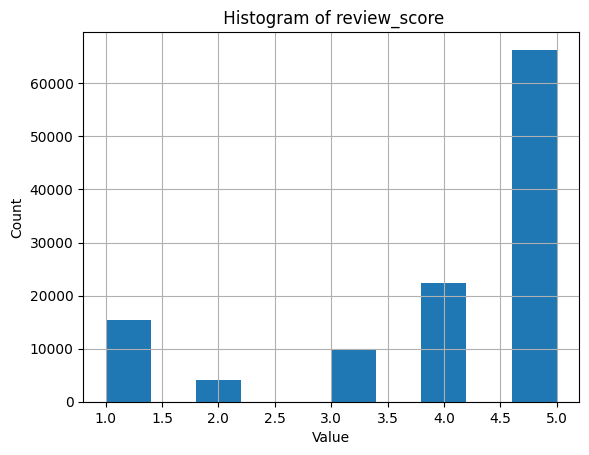

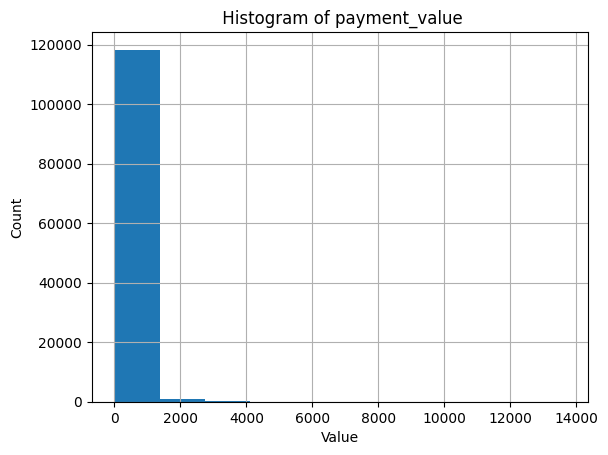

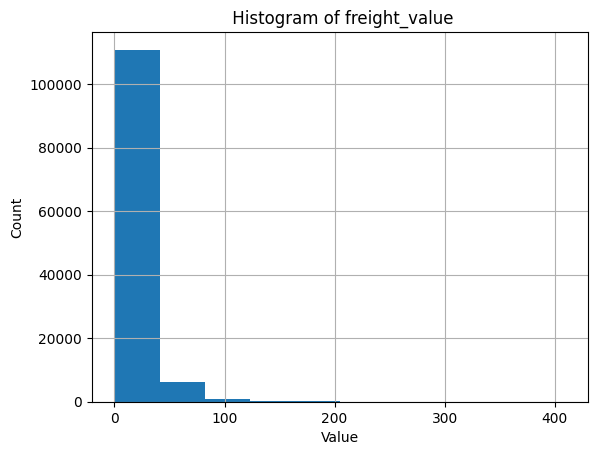

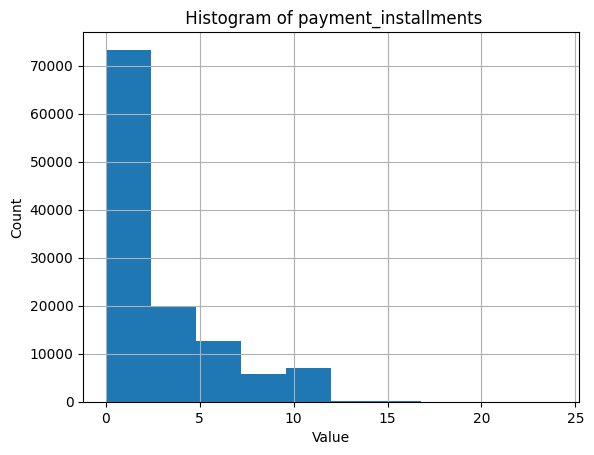

In [311]:
# histograms of selected numeric variables
for c in ["review_score","payment_value","freight_value","payment_installments"]:
  merged_df[c].hist()
  plt.title(f" Histogram of {c}")
  plt.ylabel("Count")
  plt.xlabel("Value")
  plt.show()

In [312]:
# visualizing categorical data

# subset only categorical columns and obtain the no. of unique categories and the name of the most frequent category
merged_df.select_dtypes(include=['object']).describe().T

,count,unique,top,freq
order_id,119140,99440,895ab968e7bb0d5659d16cd74cd1650c,63
payment_type,119140,5,credit_card,87776
product_id,118307,32951,aca2eb7d00ea1a7b8ebd4e68314663af,536
seller_id,118307,3095,4a3ca9315b744ce9f8e9374361493884,2155
shipping_limit_date,118307,93317,2017-08-14 20:43:31,63
review_id,118143,98409,eef5dbca8d37dfce6db7d7b16dd0525e,63
review_comment_title,13989,4527,Recomendo,494
review_comment_message,50242,36158,Muito bom,259
review_creation_date,118143,635,2017-12-19 00:00:00,547
review_answer_timestamp,118143,98247,2017-08-17 22:17:55,63


In [313]:
for c in merged_df.select_dtypes(include=['object']).columns:
  print( merged_df[c].unique() )

['b81ef226f3fe1789b1e8b2acac839d17' 'a9810da82917af2d9aefd1278f1dcfa0'
 '25e8ea4e93396b6fa0d3dd708e76c1bd' ... '32609bbb3dd69b3c066a6860554a77bf'
 'b8b61059626efa996a60be9bb9320e10' '28bbae6599b09d39ca406b747b6632b1']
['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']
['af74cc53dcffc8384b29e7abfa41902b' 'a630cc320a8c872f9de830cf121661a3'
 '2028bf1b01cafb2d2b1901fca4083222' ... '0dcb1adbafdcc389972874b01fa249b8'
 'fea2f92877b647dc07ea8e3f4aa2cf3f' '848ef0a103ee21407d1fbd0f7e7ae179']
['213b25e6f54661939f11710a6fddb871' 'eaf6d55068dea77334e8477d3878d89e'
 'cc419e0650a3c5ba77189a1882b7556a' ... 'c7246702dc991a06d788120dc7544391'
 '52831e5990d0771cb4951d6f12928167' 'e116c7455dd26a4d8c3e92532583905f']
['2018-05-02 22:15:09' '2018-07-02 11:18:58' '2017-12-26 09:52:34' ...
 '2018-05-22 12:30:57' '2017-11-27 17:46:05' '2018-08-13 23:45:00']
['4ce650e117a5b292bf5ea980a61eb61e' 'ad2036caca61484fc435d7e673c020f2'
 'bcddfa0f7d2e54cfc74bae4f01b84d92' ... '2cdb88f8dce688bb85e20a5cf069e589'

In [314]:
merged_df["seller_city"].value_counts().nlargest(10)

,count
seller_city,
sao paulo,29293
ibitinga,8373
curitiba,3158
santo andre,3149
sao jose do rio preto,2693
belo horizonte,2688
rio de janeiro,2535
guarulhos,2456
ribeirao preto,2374


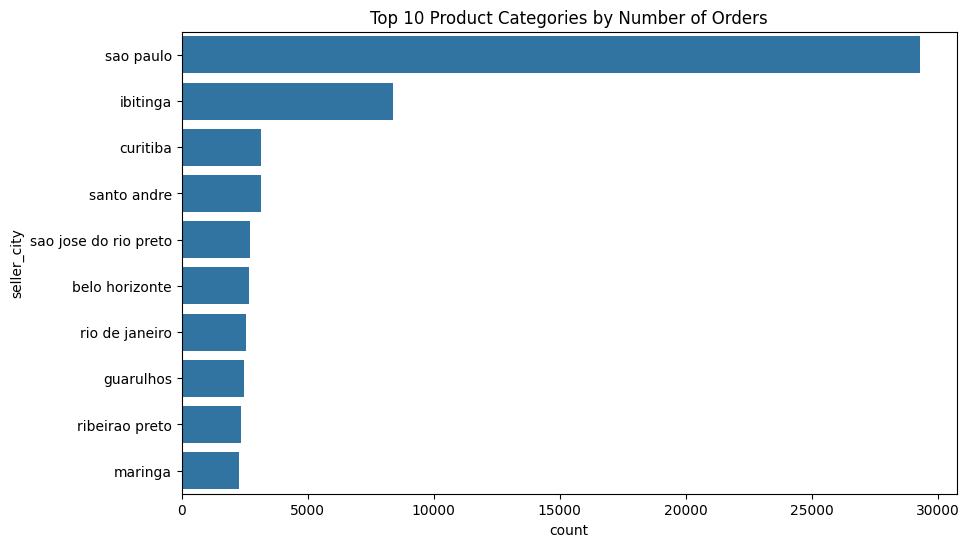

In [315]:
# Get the top 10 categories and produce a countplot
top_10 = merged_df['seller_city'].value_counts().nlargest(10).index

plt.figure(figsize=(10, 6))
sns.countplot(data=merged_df[merged_df['seller_city'].isin(top_10)],
              y='seller_city',
              order=top_10)
plt.title('Top 10 Product Categories by Number of Orders')
plt.show()

Index(['delivered', 'shipped', 'canceled', 'unavailable', 'invoiced',
       'processing', 'created', 'approved'],
      dtype='object', name='order_status')


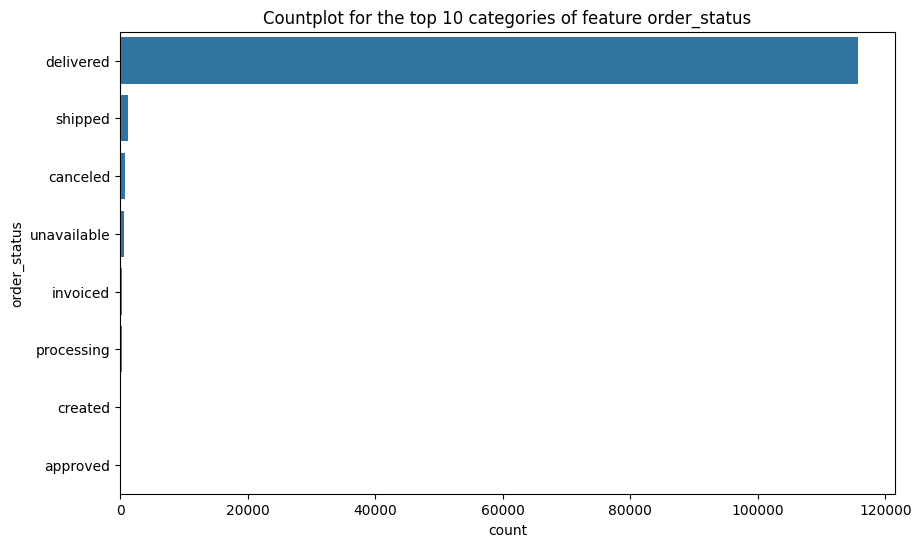

Index(['sao paulo', 'ibitinga', 'curitiba', 'santo andre',
       'sao jose do rio preto', 'belo horizonte', 'rio de janeiro',
       'guarulhos', 'ribeirao preto', 'maringa'],
      dtype='object', name='seller_city')


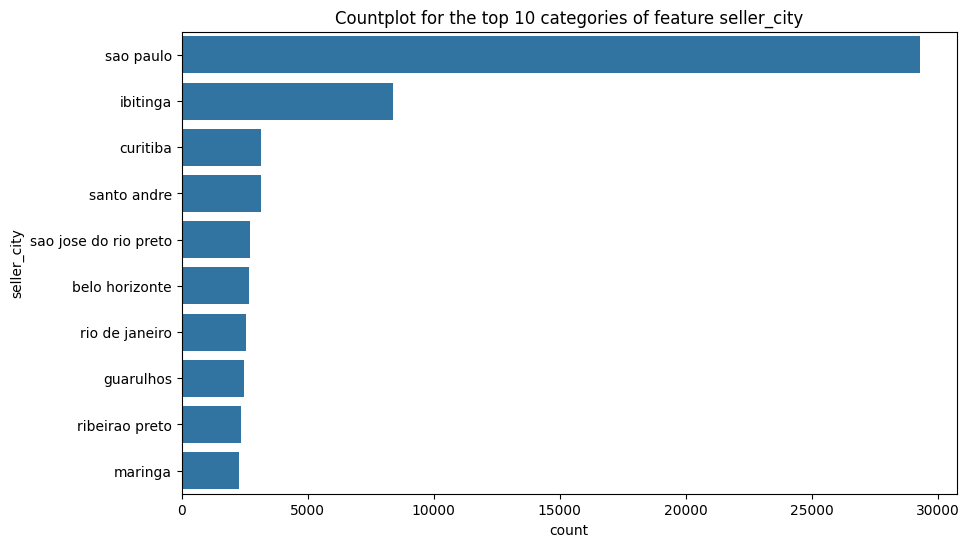

Index(['SP', 'MG', 'PR', 'RJ', 'SC', 'RS', 'DF', 'BA', 'GO', 'PE'], dtype='object', name='seller_state')


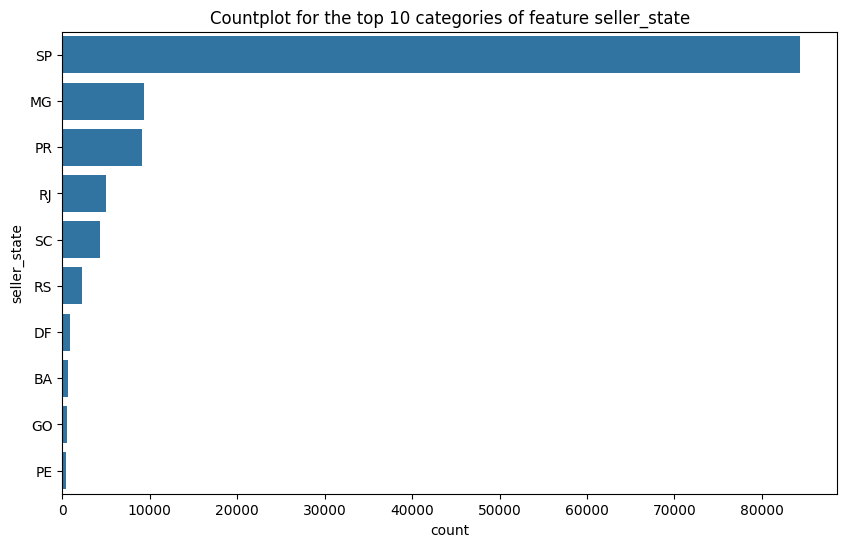

Index(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'], dtype='object', name='payment_type')


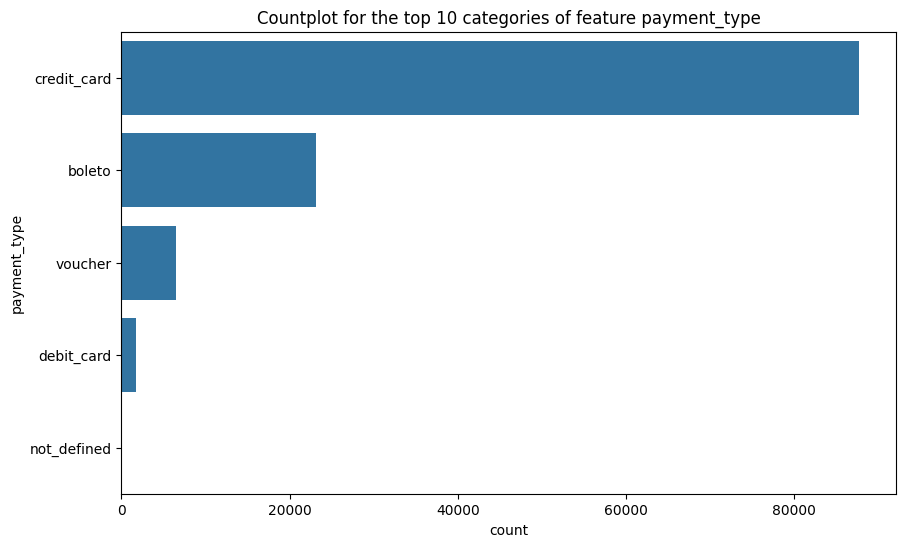

Index(['aca2eb7d00ea1a7b8ebd4e68314663af', '99a4788cb24856965c36a24e339b6058',
       '422879e10f46682990de24d770e7f83d', '389d119b48cf3043d311335e499d9c6b',
       '368c6c730842d78016ad823897a372db', '53759a2ecddad2bb87a079a1f1519f73',
       'd1c427060a0f73f6b889a5c7c61f2ac4', '53b36df67ebb7c41585e8d54d6772e08',
       '154e7e31ebfa092203795c972e5804a6', '3dd2a17168ec895c781a9191c1e95ad7'],
      dtype='object', name='product_id')


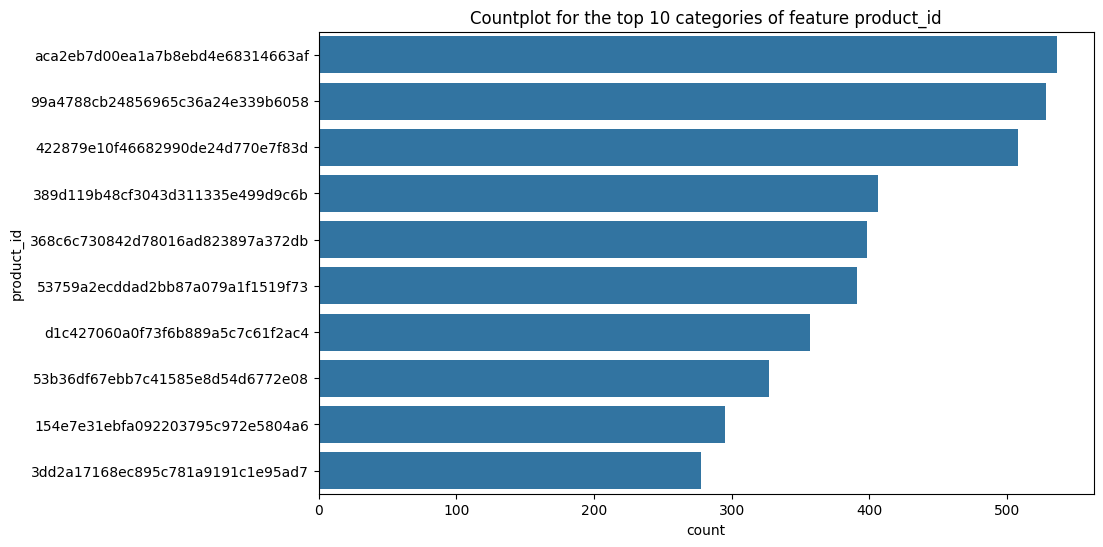

Index(['sao paulo', 'rio de janeiro', 'belo horizonte', 'brasilia', 'curitiba',
       'campinas', 'porto alegre', 'salvador', 'guarulhos',
       'sao bernardo do campo'],
      dtype='object', name='customer_city')


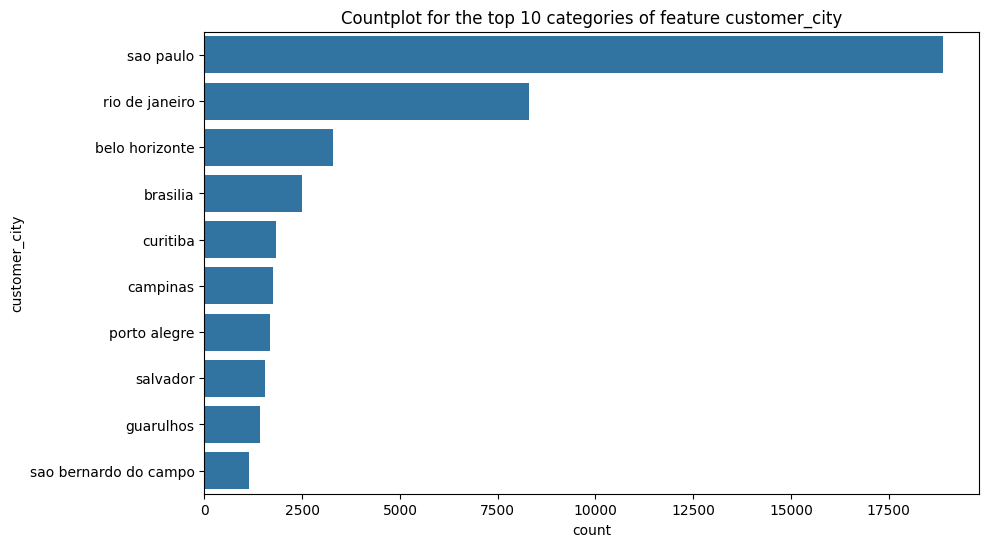

Index(['SP', 'RJ', 'MG', 'RS', 'PR', 'SC', 'BA', 'DF', 'GO', 'ES'], dtype='object', name='customer_state')


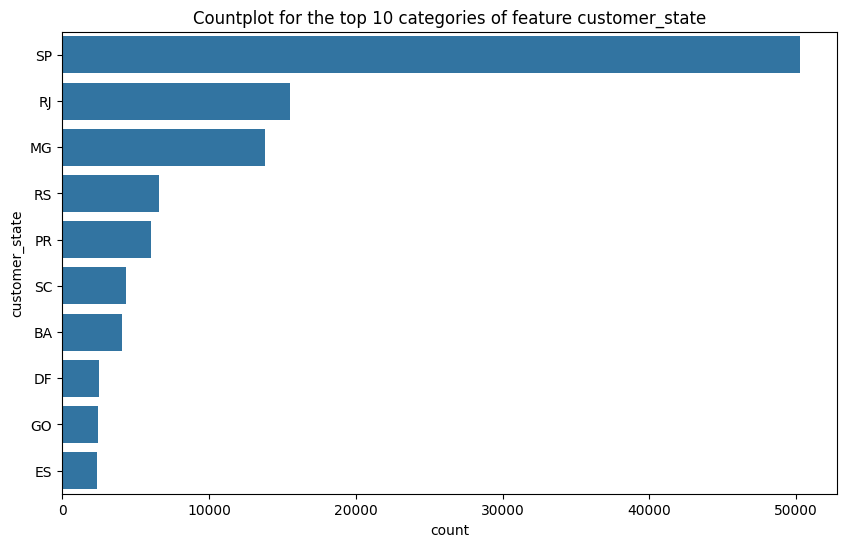

In [316]:
# countplots of top 10 categories of selected categorical variables
for c in ["order_status","seller_city","seller_state","payment_type","product_id","customer_city","customer_state"]:
  top_10 = merged_df[c].value_counts().nlargest(10).index # get the top 10 category names
  print(top_10)

  # countplot
  plt.figure(figsize=(10, 6))
  sns.countplot(data=merged_df[merged_df[c].isin(top_10)],
              y=c,
              order=top_10)
  plt.title(f'Countplot for the top 10 categories of feature {c}')
  plt.show()

## RFM Customer Analysis with K-means

### preprocessing and transformations


*   **Recency**: Since we need to calculate numerical distances, we habe to count the no. of days between the most recent order in the entire dataset and each customer's last purchase date
*   **Frequency:**  the idea is to  count unique order_id values and grouping by customer_id. In the Olist dataset, one order can have multiple items (rows), so count() might over-represent frequency if you don't use nunique().
*   **Monetary:** Grouping sum(price) by customer_id works but for a complete picture, one could sum price + freight_value



In [329]:
merged_df.info()
# Recent: order_purchase_timestamp grouped by customer_unique_id,
# Frequent: n_unique(order_id) grouped by customer_unique_id ,
# Monetary: sum(price) + sum(freight_value) grouped by customer_unique_id

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119140 entries, 0 to 119139
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119140 non-null  object        
 1   payment_sequential             119140 non-null  int64         
 2   payment_type                   119140 non-null  object        
 3   payment_installments           119140 non-null  int64         
 4   payment_value                  119140 non-null  float64       
 5   order_item_id                  118307 non-null  float64       
 6   product_id                     118307 non-null  object        
 7   seller_id                      118307 non-null  object        
 8   shipping_limit_date            118307 non-null  object        
 9   price                          118307 non-null  float64       
 10  freight_value                  118307 non-null  float64       
 11  

In [330]:
# new independent df for the RFM analysis in which each row corresponds to a unique customer
rfm_df = pd.DataFrame()

rfm_df

""


In [331]:
# summing price and freight values before grouping by unique customer
# make sure thathe indices of the rmf_df and the groupby result align
merged_df["total_value"] = merged_df["price"] + merged_df["freight_value"]

# intermediate column
print(merged_df["total_value"])

# adding the feature of interest to the separate dataframe
rfm_df["monetary"] = merged_df["total_value"].groupby(merged_df["customer_unique_id"]).sum()

rfm_df["monetary"]

0          99.33
1          24.39
2          65.71
3         107.78
4         107.78
           ...  
119135    363.31
119136     96.80
119137     47.77
119138    369.54
119139    191.58
Name: total_value, Length: 119140, dtype: float64


,monetary
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19
0000f46a3911fa3c0805444483337064,86.22
0000f6ccb0745a6a4b88665a16c9f078,43.62
0004aac84e0df4da2b147fca70cf8255,196.89
...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2067.42
fffea47cd6d3cc0a88bd621562a9d061,84.58
ffff371b4d645b6ecea244b27531430a,112.46


In [332]:
rfm_df["monetary"].isnull().sum() # double check: no NA values created

np.int64(0)

In [333]:
# the dataframe has 99440 rows but we have 96095 unique customer ids due to repeated purchases
# customer_id is unique to each order, while customer_unique_id tracks returning customers
rfm_df["frequency"] = merged_df["order_id"].groupby(merged_df["customer_unique_id"]).nunique() # take the column, then look at a different series for grouping

rfm_df["frequency"]#.value_counts()

,frequency
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1
...,...
fffcf5a5ff07b0908bd4e2dbc735a684,1
fffea47cd6d3cc0a88bd621562a9d061,1
ffff371b4d645b6ecea244b27531430a,1


In [334]:
# step 1 for recency: converting the timestamp to datetime format
merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])

print(merged_df['order_purchase_timestamp'])



0        2018-04-25 22:01:49
1        2018-06-26 11:01:38
2        2017-12-12 11:19:55
3        2017-12-06 12:04:06
4        2017-12-06 12:04:06
                 ...        
119135   2018-03-08 16:57:23
119136   2017-08-18 09:45:35
119137   2017-11-18 17:27:14
119138   2018-08-07 23:26:13
119139   2017-12-05 08:18:35
Name: order_purchase_timestamp, Length: 119140, dtype: datetime64[ns]


In [335]:
# step 2 for recency: creating series for today and for the latest purchase

# define "today" as one day after the very last purchase in the data and store the result in a series
now = merged_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print(now)

# last purchase date per unique customer (series)
latest_purchase = merged_df['order_purchase_timestamp'].groupby(merged_df["customer_unique_id"]).max() # latest purchase by customer

print(latest_purchase)


2018-10-18 17:30:18
customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2   2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f   2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064   2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078   2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255   2017-11-14 19:45:42
                                           ...        
fffcf5a5ff07b0908bd4e2dbc735a684   2017-06-08 21:00:36
fffea47cd6d3cc0a88bd621562a9d061   2017-12-10 20:07:56
ffff371b4d645b6ecea244b27531430a   2017-02-07 15:49:16
ffff5962728ec6157033ef9805bacc48   2018-05-02 15:17:41
ffffd2657e2aad2907e67c3e9daecbeb   2017-05-02 20:18:45
Name: order_purchase_timestamp, Length: 96095, dtype: datetime64[ns]


In [336]:
# step 3 for recency: subtract the latest_purchase date from the now datetime object and measure the difference in days
# First, finish the subtraction to create the Timedelta Series. Then, use the .dt tool on that result to extract only the days.
rfm_df["recency"] = (now - latest_purchase).dt.days

# most advanced alternative: List Comprehension with Lambda
# 'group' is the Series of timestamps for each customer
##rfm_df['recency'] = [ (lambda x: (now - x.max() ).days)(group) for name, group in merged_df['order_purchase_timestamp'].groupby(merged_df['customer_unique_id']) ]


rfm_df["recency"]

,recency
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,161
0000b849f77a49e4a4ce2b2a4ca5be3f,164
0000f46a3911fa3c0805444483337064,586
0000f6ccb0745a6a4b88665a16c9f078,370
0004aac84e0df4da2b147fca70cf8255,337
...,...
fffcf5a5ff07b0908bd4e2dbc735a684,496
fffea47cd6d3cc0a88bd621562a9d061,311
ffff371b4d645b6ecea244b27531430a,618


In [337]:
# reordering the columns
rfm_df = rfm_df[['recency', 'frequency', 'monetary']]

rfm_df

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89
...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42
fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58
ffff371b4d645b6ecea244b27531430a,618,1,112.46


In [338]:
rfm_df.describe().T

,count,mean,std,min,25%,50%,75%,max
recency,96095.0,288.730756,153.407846,1.0,164.00,269.00,398.0,773.00
frequency,96095.0,1.034809,0.214385,1.0,1.00,1.00,1.0,17.00
monetary,96095.0,173.199312,264.151761,0.0,63.27,109.82,188.2,13664.08


In [327]:
#import scipy.stats
#scipy.stats.describe(rfm_df) # incl skewness and kurtosis

# applying both the skew() and the kurt() method to aggregate the dataframe
# normal distribution has a skewness of 0 and a kurtosis of 3
# all of them are non-normal
rfm_df.agg(["skew","kurt"]).T

,skew,kurt
monetary,11.796529,324.459224
recency,0.445310,-0.655052


before running the k-means algorithm, we need to handle the following aspects:
*  skewness of the monetary data by applying a log-transformation. K-means assumes your data is distributed somewhat symmetrically. Log transformation pulls those extreme "outlier" spenders closer to the average, creating a more "normal" (bell-shaped) distribution
*  normalizing all three features so they have mean 0 and st dev of 1 using standard scaler

array([[<Axes: title={'center': 'monetary'}>,
        <Axes: title={'center': 'recency'}>]], dtype=object)

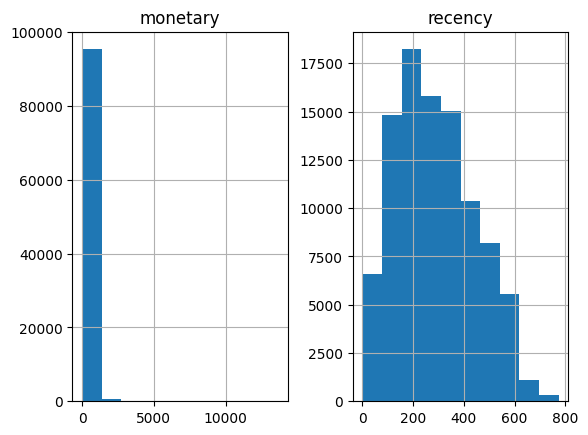

In [328]:
rfm_df.hist()

In [339]:
# log-transformation
rfm_df_log = np.log1p(rfm_df)

# summary stats for the log-transformed numpy array
pd.DataFrame(rfm_df_log,
             columns=["recency","frequency","monetary"]).describe().T

,count,mean,std,min,25%,50%,75%,max
recency,96095.0,5.501999,0.616752,0.693147,5.105945,5.598422,5.988961,6.651572
frequency,96095.0,0.706732,0.078259,0.693147,0.693147,0.693147,0.693147,2.890372
monetary,96095.0,4.725101,0.914325,0.000000,4.163093,4.707907,5.242805,9.522599


In [340]:
# summary stats for the log-transformed numpy array
pd.DataFrame(rfm_df_log,
             columns=["recency","frequency","monetary"]).agg(["skew","kurt"]).T

,skew,kurt
recency,-0.563126,-0.435452
frequency,6.396742,50.566829
monetary,-0.469574,4.474239


array([[<Axes: title={'center': 'recency'}>,
        <Axes: title={'center': 'frequency'}>],
       [<Axes: title={'center': 'monetary'}>, <Axes: >]], dtype=object)

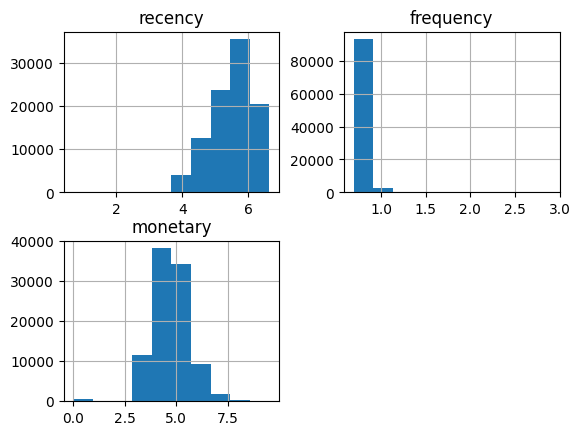

In [341]:
rfm_df_log.hist()

In [342]:
stdnorm_scaler = StandardScaler()
rfm_df_stdnormscaled = stdnorm_scaler.fit_transform(rfm_df_log)

In [343]:
type(rfm_df_stdnormscaled)

numpy.ndarray

In [344]:
rfm_df_stdnormscaled#.describe().T

array([[-0.6719146 , -0.173594  ,  0.25925773],
       [-0.64216322, -0.173594  , -1.51602607],
       [ 1.41552805, -0.173594  , -0.28071879],
       ...,
       [ 1.50159295, -0.173594  ,  0.00694487],
       [-0.59375949, -0.173594  ,  0.1945438 ],
       [ 1.26209617, -0.173594  , -0.48198293]])

In [345]:
# summary stats for the scaled numpy array
pd.DataFrame(rfm_df_stdnormscaled,
             columns=["recency","frequency","monetary"]).describe().T


,count,mean,std,min,25%,50%,75%,max
recency,96095.0,4.945221e-16,1.000005,-7.797095,-0.642163,0.156340,0.789563,1.863923
frequency,96095.0,8.135065e-16,1.000005,-0.173594,-0.173594,-0.173594,-0.173594,27.902904
monetary,96095.0,-6.824819e-17,1.000005,-5.167884,-0.614673,-0.018804,0.566218,5.247066


In [346]:
# summary stats for the log-transformed numpy array
pd.DataFrame(rfm_df_stdnormscaled,
             columns=["recency","frequency","monetary"]).agg(["skew","kurt"]).T

,skew,kurt
recency,-0.563126,-0.435452
frequency,6.396742,50.566829
monetary,-0.469574,4.474239


array([[<Axes: title={'center': 'recency'}>,
        <Axes: title={'center': 'frequency'}>],
       [<Axes: title={'center': 'monetary'}>, <Axes: >]], dtype=object)

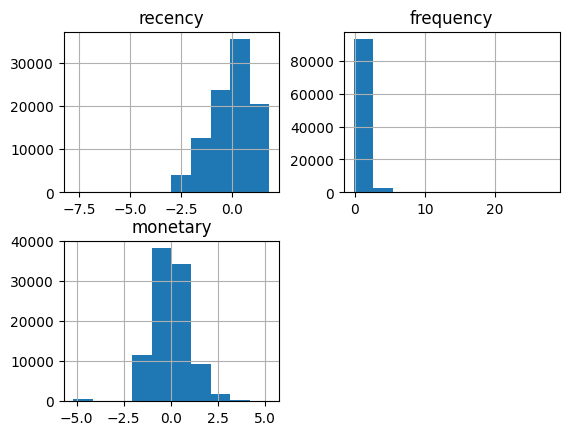

In [347]:
pd.DataFrame(rfm_df_stdnormscaled, columns=["recency","frequency","monetary"]).hist()

In [348]:
# storing the log-transformed and stdnorm-scaled data in a pd df again
rfm_final_df = pd.DataFrame(rfm_df_stdnormscaled, index=rfm_df.index, columns=rfm_df.columns)

rfm_final_df

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,-0.671915,-0.173594,0.259258
0000b849f77a49e4a4ce2b2a4ca5be3f,-0.642163,-0.173594,-1.516026
0000f46a3911fa3c0805444483337064,1.415528,-0.173594,-0.280719
0000f6ccb0745a6a4b88665a16c9f078,0.671591,-0.173594,-1.013779
0004aac84e0df4da2b147fca70cf8255,0.520547,-0.173594,0.615332
...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,1.145670,-0.173594,3.182080
fffea47cd6d3cc0a88bd621562a9d061,0.390765,-0.173594,-0.301480
ffff371b4d645b6ecea244b27531430a,1.501593,-0.173594,0.006945


### k-means algorithm




The elbow method lets us graph the inertia (a distance-based metric) and visualize the point at which it starts decreasing linearly. This point is referred to as the "elbow" and is a good estimate for the best value for K based on our data

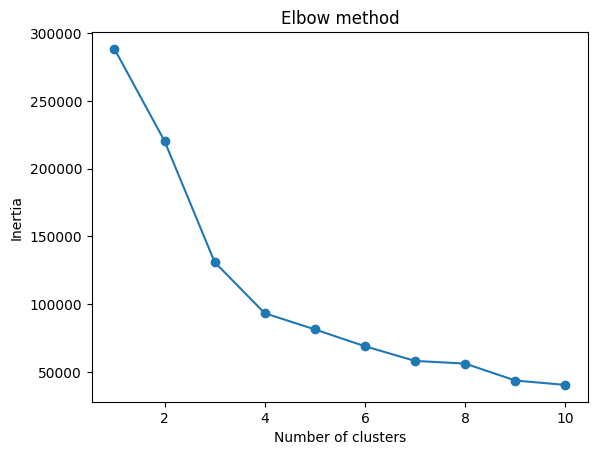

In [349]:
inertias = [] # empty list

for i in range(1,11): # looping over 1-11 clusters
    kmeans = KMeans(n_clusters=i # no. of clusters and centroids to generate
                    )
    kmeans.fit(rfm_final_df)
    inertias.append(kmeans.inertia_) # appending the inertia values to the list

plt.plot(range(1,11), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [350]:
# we will pick 4 clusters and group our data into 4 clusters
k_opt = 6

kmeans = KMeans(n_clusters=k_opt, # no. of clusters to generate
                random_state=123 # centroid initialization
                )


# run kmeans on the scaled data, but assign labels to the original (unscaled) dataframe
rfm_df['cluster'] = kmeans.fit_predict(rfm_final_df)




kmeans.n_iter_ # no. of iterations needed


/tmp/ipykernel_5893/111783182.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df['cluster'] = kmeans.fit_predict(rfm_final_df)


73

In [351]:
rfm_df

,recency,frequency,monetary,cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,5
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,0
0000f46a3911fa3c0805444483337064,586,1,86.22,2
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,0
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42,1
fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,2
ffff371b4d645b6ecea244b27531430a,618,1,112.46,2


In [352]:
# See how many customers are in each cluster
print(rfm_df['cluster'].value_counts())



cluster
2    25319
5    22524
0    18072
4    15783
1    11400
3     2997
Name: count, dtype: int64


In [405]:
# Calculate the RFM values mean, min and max values for each customer segment
cluster_analysis = rfm_df.groupby(rfm_df['cluster']).agg({
    "recency":["mean","median","min","max","std"],
    "frequency":["mean","median","min","max","std"],
    "monetary":["mean","median","min","max","std"],
    "cluster": "count" # extra column with the count per segment
}).T


cluster_analysis.rename(columns={'cluster': 'cluster_count'}).round(2)

cluster                  0         1         2        3         4         5
recency   mean      347.14    290.29    444.29   269.21     90.09    208.01
          median    327.00    275.00    435.00   249.00     86.00    205.00
          min        42.00     53.00    286.00     1.00      1.00    123.00
          max       765.00    744.00    773.00   741.00    144.00    306.00
          std       121.48    126.84     99.10   145.35     23.23     45.15
frequency mean        1.00      1.00      1.00     2.12      1.00      1.00
          median      1.00      1.00      1.00     2.00      1.00      1.00
          min         1.00      1.00      1.00     2.00      1.00      1.00
          max         1.00      1.00      1.00    17.00      1.00      1.00
          std         0.00      0.00      0.00     0.52      0.00      0.00
monetary  mean       42.05    581.63    138.01   345.70    123.02    123.48
          median     42.32    411.62    124.10   243.86     96.88    114.42
          min         0.00    215.57     48.55     0.00      0.00     38.13
          max        75.07  13664.08    467.20  7571.63   1024.76    291.44
          std        15.01    556.35     61.25   389.20     93.23     50.81
cluster   count   18072.00  11400.00  25319.00  2997.00  15783.00  22524.00

In [376]:
# Calculate the RFM means by cluster
cluster_means = rfm_df[['recency', 'frequency', 'monetary']].groupby(rfm_df['cluster']).mean()



cluster_means

,recency,frequency,monetary
cluster,,,
0,347.136786,1.000000,42.048839
1,290.285789,1.000000,581.631922
2,444.290770,1.000000,138.005425
3,269.206874,2.116116,345.704968
4,90.091427,1.000000,123.020436
5,208.006748,1.000000,123.477563


In [377]:
global_means = rfm_df[['recency', 'frequency', 'monetary']].mean()


global_means

,0
recency,288.730756
frequency,1.034809
monetary,173.199312


In [379]:
# ratio of the two means: relative importance
# 0 represents an average customer
# a high positive recency value is bad (purchase dates back long ago), i.e. in clusters 0 and 2 customers bought a while ago
# in cluter 4, customers bought more recently
# only cluster 3 has a positive frequency value i.e. there are repeat buyers; in the other clusters, there are only one-time buyers
# clusters 3 and 1 have the highest positive monetary importance values so those customers spend the most
relative_importance = (cluster_means / global_means) -1
print(relative_importance)

          recency  frequency  monetary
cluster                               
0        0.202285  -0.033638 -0.757223
1        0.005386  -0.033638  2.358165
2        0.538772  -0.033638 -0.203199
3       -0.067620   1.044933  0.995995
4       -0.687974  -0.033638 -0.289718
5       -0.279582  -0.033638 -0.287078


In [413]:
relative_importance.index

Index([0, 1, 2, 3, 4, 5], dtype='int32', name='cluster')

In [415]:
# relabeling the clusters with the customer segments
relative_importance.rename(index=cluster_label_map, inplace=True)

In [417]:
heatmap_data = relative_importance.copy()
# multiplying the recency importances by -1 to account for the fact that a positive value means the purchase happened in the past
# now the positive values mean more recent purchases and the negative values mean less recent purchases
heatmap_data['recency'] = heatmap_data['recency'] * -1


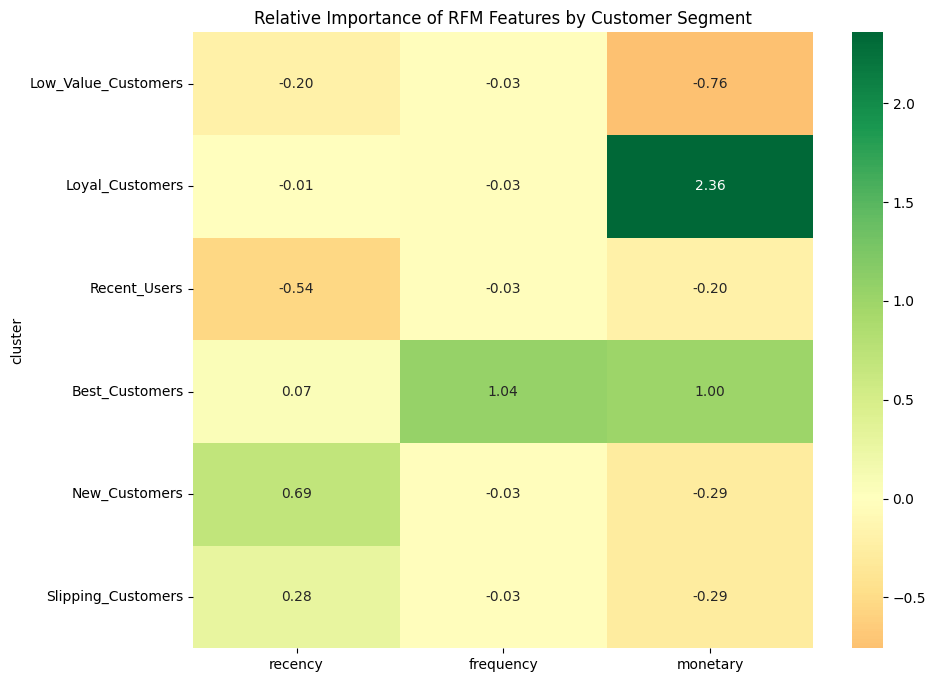

In [418]:
# heatmap visualization
plt.figure(figsize=(10, 8))

# annot=True adds the numbers to the cells
# fmt=".2f" keeps decimals clean
# cmap='RdYlGn' makes "good" values green and "bad" values red
sns.heatmap(heatmap_data,
            annot=True,
            fmt=".2f",
            cmap='RdYlGn',
            center=0
            )

plt.title('Relative Importance of RFM Features by Customer Segment')
plt.show()

Now we can analyze the cluster characteristics and compare across the clusters:

* Champions/Best Customers: Lowest recency, highest frequency, highest monetary value. They buy often and recently.
* Loyal Customers/Whales: High frequency and high monetary value, moderate to low recency.
* At-Risk/Slipping Customers: High recency (bought long ago), but previously high frequency/monetary value.
* Potential Loyalists/Recent Users: Low recency (bought recently), low frequency, moderate spending.
* New Customers/Promising: Low recency (new), low frequency, low spending.
* Lost/Low-Value: High recency, low frequency, low monetary value



*   Recency tells you who is still an active customer
*   Monetary tells you who pays the bills



In [381]:
# renaming the cluster labels by using a dictionary
cluster_label_map = {
    3: 'Best_Customers',       # Highest frequency, 2nd highest monetary
    1: 'Loyal_Customers',      # moderate recency, highest monetary, average frequency
    5: 'Slipping_Customers',   # 2nd lowest monetary (tie), 2nd lowest recency (bought recently)
    2: 'Recent_Users',         # Very high recency, low frequency, medium monetary (still below average)
    4: 'New_Customers',         # lowest recency, 2nd lowest monetary (tie)
    0: 'Low_Value_Customers'   # High recency (bought long ago), low monetary
}

rfm_df["customer_segment"] = rfm_df["cluster"].map(cluster_label_map)


/tmp/ipykernel_5893/2576613725.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_df["customer_segment"] = rfm_df["cluster"].map(cluster_label_map)


In [382]:
rfm_df

,recency,frequency,monetary,cluster,customer_segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,5,Slipping_Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,0,Low_Value_Customers
0000f46a3911fa3c0805444483337064,586,1,86.22,2,Recent_Users
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,0,Low_Value_Customers
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,Recent_Users
...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42,1,Loyal_Customers
fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,2,Recent_Users
ffff371b4d645b6ecea244b27531430a,618,1,112.46,2,Recent_Users


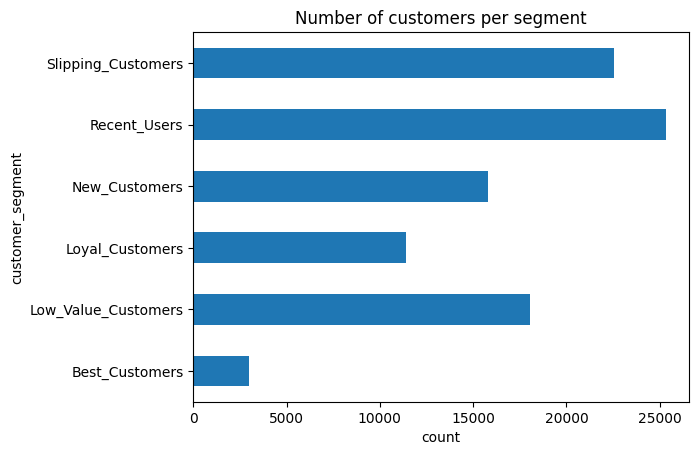

In [395]:
rfm_df["customer_segment"].groupby(rfm_df["customer_segment"]).count().plot.barh()
plt.xlabel("count")
plt.title("Number of customers per segment")
plt.show()

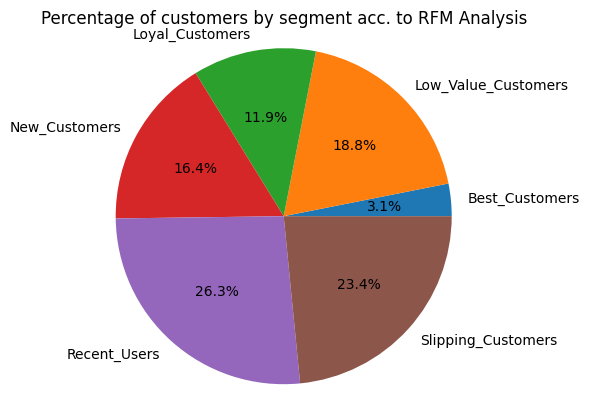

In [421]:
# pie chart of customer segments
# autopct='%1.1f%%' means that percentages are displayed with 1 digit before and 1 after the decimal point
rfm_df["customer_segment"].groupby(rfm_df["customer_segment"]).count().plot.pie(autopct='%1.1f%%')
plt.axis("equal") # perfect circle
plt. ylabel("") # no yaxis label
plt.title("Percentage of customers by segment acc. to RFM Analysis")
plt.show()

In [407]:
# Rename the columns using the dictionary
cluster_analysis.rename(columns=cluster_label_map, inplace=True)

cluster_analysis.round(2)

cluster           Low_Value_Customers  Loyal_Customers  Recent_Users  \
recency   mean                 347.14           290.29        444.29   
          median               327.00           275.00        435.00   
          min                   42.00            53.00        286.00   
          max                  765.00           744.00        773.00   
          std                  121.48           126.84         99.10   
frequency mean                   1.00             1.00          1.00   
          median                 1.00             1.00          1.00   
          min                    1.00             1.00          1.00   
          max                    1.00             1.00          1.00   
          std                    0.00             0.00          0.00   
monetary  mean                  42.05           581.63        138.01   
          median                42.32           411.62        124.10   
          min                    0.00           215.57         48.55   
          max                   75.07         13664.08        467.20   
          std                   15.01           556.35         61.25   
cluster   count              18072.00         11400.00      25319.00   

cluster           Best_Customers  New_Customers  Slipping_Customers  
recency   mean            269.21          90.09              208.01  
          median          249.00          86.00              205.00  
          min               1.00           1.00              123.00  
          max             741.00         144.00              306.00  
          std             145.35          23.23               45.15  
frequency mean              2.12           1.00                1.00  
          median            2.00           1.00                1.00  
          min               2.00           1.00                1.00  
          max              17.00           1.00                1.00  
          std               0.52           0.00                0.00  
monetary  mean            345.70         123.02              123.48  
          median          243.86          96.88              114.42  
          min               0.00           0.00               38.13  
          max            7571.63        1024.76              291.44  
          std             389.20          93.23               50.81  
cluster   count          2997.00       15783.00            22524.00

# discarded

 Dynamic Pricing model for revenue maximization

 log-log price elasticity model

for revenue maximization, we want to find the price that maximizes revenue, i.e. the price times the demanded quantity demanded at price $p$, which gives way to the following optimization problem:      $$\quad \max_{ \{p\} } \{ p \times d(p) \}$$

since demand is a function of price, we will model the demand function as a log-log model, which  relates the log of the quantity demanded to the log of the chosen price, indicating that a 1% change in price results in a fixed percentage change in the quantity demanded $$log(d(p))= a + b*log(p) ≡ d(p)= e^{a}+p^{b}$$

however, in this data set, we don't have information about the quantities sold so we need to use the purchase probability column as a proxy